In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
JH31 = pd.read_csv("JH31.txt", sep="\t")
JH15 = pd.read_csv("JH15.txt", sep="\t")
JH58 = pd.read_csv("JH58.txt", sep="\t")
JH65 = pd.read_csv("JH65.txt", sep="\t")
JHamp = pd.read_csv("JHamp.txt", sep="\t")

In [3]:
JH31 = JH31[['T: Genes',"N: Student's T-test Difference JH31_DF", "N: -Log Student's T-test p-value JH31_DF"]]
JH15 = JH15[['T: Genes',"N: Student's T-test Difference JH15_DH", "N: -Log Student's T-test p-value JH15_DH"]]
JH58 = JH58[['T: Genes',"N: Student's T-test Difference JH58_DK", "N: -Log Student's T-test p-value JH58_DK"]]
JH65 = JH65[['T: Genes',"N: Student's T-test Difference JH65_DL", "N: -Log Student's T-test p-value JH65_DL"]]
JHamp = JHamp[['T: Genes',"N: Student's T-test Difference JHamp_DI", "N: -Log Student's T-test p-value JHamp_DI"]]

In [4]:
# threshold on –log10 p-value  
THRESH = 1.3            # ≈ –log10(0.05)

# ( dataframe, “difference” column, “p-value” column )
targets = [
    (JH31, "N: Student's T-test Difference JH31_DF", "N: -Log Student's T-test p-value JH31_DF"),
    (JH15, "N: Student's T-test Difference JH15_DH", "N: -Log Student's T-test p-value JH15_DH"),
    (JH58, "N: Student's T-test Difference JH58_DK", "N: -Log Student's T-test p-value JH58_DK"),
    (JH65, "N: Student's T-test Difference JH65_DL", "N: -Log Student's T-test p-value JH65_DL"),
    (JHamp,"N: Student's T-test Difference JHamp_DI","N: -Log Student's T-test p-value JHamp_DI"),
]

for df, diff_col, p_col in targets:
    # wherever –log10 p < 1.3 (≈ p > 0.05) → set diff to 0
    df.loc[df[p_col] < THRESH, diff_col] = 0


In [ ]:
# 1️⃣  Gather the six numeric series into a single table
diff_df = pd.DataFrame({
    'Nitrofurantoin':  JH31["N: Student's T-test Difference JH31_DF"],
    'Nitrofurazone':  JH58["N: Student's T-test Difference JH58_DK"],
    'D8':  JH65["N: Student's T-test Difference JH65_DL"],
    'Tetracycline':  JH15["N: Student's T-test Difference JH15_DH"],
    'Ampicillin': JHamp["N: Student's T-test Difference JHamp_DI"],
})

# 2️⃣  Optional clean-up:
#     - Any column that is now all-zeros (or constant) gives NaN correlations.
#       Drop them if you see NaNs or warnings.
diff_df = diff_df.loc[:, diff_df.nunique() > 1]

# 3️⃣  Correlation matrix (Pearson by default)
corr = diff_df.corr(method='pearson')

# 4️⃣  Pretty DataFrame view (interactive in Jupyter / VS Code etc.)
corr.style.background_gradient(cmap='coolwarm').format(precision=2)


,Nitrofurantoin,Nitrofurazone,D8,Tetracycline,Ampicillin
Nitrofurantoin,1.00,0.74,0.74,0.47,0.12
Nitrofurazone,0.74,1.00,0.82,0.46,0.15
D8,0.74,0.82,1.00,0.45,0.14
Tetracycline,0.47,0.46,0.45,1.00,0.11
Ampicillin,0.12,0.15,0.14,0.11,1.00


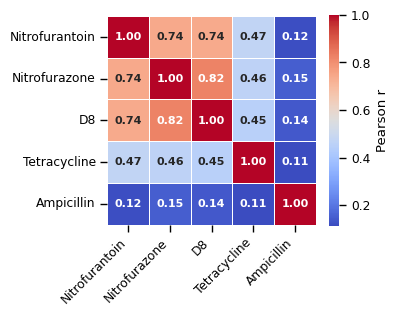

In [ ]:
plt.figure(figsize=(4, 4))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size': 8, 'weight': 'bold'},     # ← smaller numbers inside the boxes
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5,
    square=True,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.66}  # keep bar aligned
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
sns.set_context("paper")
plt.tight_layout()
plt.show()